NGC6791 J19213390+3750202 (Calibration star):   
Temperature: 3956 K     
Surface Gravity: 1.0    
Overall Metallicity: 0.18   
α elements: 0.17    

NE1-1 001:  
Temperature: 3029 K     
Surface Gravity: 1.0    
Overall Metallicity: 0.14   
α elements: -0.01   

NE1-1 002:  
Temperature: 3294 K     
Surface Gravity: 1.0    
Overall Metallicity: >0.6   
α elements: -0.01   

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
import warnings

warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.ndimage as nd
from astropy.io import fits
from astropy import units as u
from src.funcs import (
    bass_compare,
    continuum_visualizer,
    convert_wavelength_air2vacuum,
    show_plots,
    simulation,
)
from stardis.base import run_stardis

Iterations:          0/? [00:00<?, ?it/s]

Packets:             0/? [00:00<?, ?it/s]

In [2]:
'''
# IGNORE CELL
obs_w_lambda = 1 * u.Angstrom
obs_df = pd.read_csv("../data/getSolarSpectrumDB.dat", skipinitialspace=True)
obs_wave = convert_wavelength_air2vacuum(obs_df.iloc[:, 0])
obs_flux = obs_df.iloc[:, 1]
'''

'\n# IGNORE CELL\nobs_w_lambda = 1 * u.Angstrom\nobs_df = pd.read_csv("../data/getSolarSpectrumDB.dat", skipinitialspace=True)\nobs_wave = convert_wavelength_air2vacuum(obs_df.iloc[:, 0])\nobs_flux = obs_df.iloc[:, 1]\n'

In [3]:
'''
# Stardis Simulation made by using MARCS file for Calibration Star
sim_delta_lambda = 0.01 * u.Angstrom

tracing_wavelengths = np.mgrid[6061 : 7061 : sim_delta_lambda.value] * u.Angstrom
sim_full = run_stardis("calibration.yml", tracing_wavelengths)
sim_nolines = run_stardis("calibration_nolines.yml", tracing_wavelengths)

sim_normalized_flux = sim_full.spectrum_lambda / sim_nolines.spectrum_lambda * 10000

obs_sigma_lambda = obs_w_lambda / 2.355
obs_sigma_pix = obs_sigma_lambda / sim_delta_lambda
sim_convolved_flux = nd.gaussian_filter1d(sim_normalized_flux, obs_sigma_pix)
'''

'\n# Stardis Simulation made by using MARCS file for Calibration Star\nsim_delta_lambda = 0.01 * u.Angstrom\n\ntracing_wavelengths = np.mgrid[6061 : 7061 : sim_delta_lambda.value] * u.Angstrom\nsim_full = run_stardis("calibration.yml", tracing_wavelengths)\nsim_nolines = run_stardis("calibration_nolines.yml", tracing_wavelengths)\n\nsim_normalized_flux = sim_full.spectrum_lambda / sim_nolines.spectrum_lambda * 10000\n\nobs_sigma_lambda = obs_w_lambda / 2.355\nobs_sigma_pix = obs_sigma_lambda / sim_delta_lambda\nsim_convolved_flux = nd.gaussian_filter1d(sim_normalized_flux, obs_sigma_pix)\n'

In [8]:
#Code for Solar Spectra
sim_sun_conv, sim_sun_lambdas = simulation("solar.yml", "solar_nolines.yml", 0.1 * u.Angstrom, start=22000, end=22100 )

In [9]:
#Code for Science Target spectra
sim_cal_conv, sim_cal_lambdas = simulation("calibration.yml", "calibration_nolines.yml", 0.1 * u.Angstrom, start=22000, end=22100)
sim_001_conv, sim_001_lambdas = simulation("001.yml", "001_nolines.yml", 0.1 * u.Angstrom, start=22000, end=22100)
sim_002_conv, sim_002_lambdas = simulation("002.yml", "002_nolines.yml", 0.1 * u.Angstrom, start=22000, end=22100 )

Outside of interpolation range for H2+ BF cross-sections at depth points [42 43 44 45 46 47 48 49 50 51 52 53 54 55]. Assuming 0 opacity from H2+BF for these depth points.
Outside of interpolation range for H2+ BF cross-sections at depth points [42 43 44 45 46 47 48 49 50 51 52 53 54 55]. Assuming 0 opacity from H2+BF for these depth points.
Outside of interpolation range for H2+ BF cross-sections at depth points [18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41
 42 43 44 45 46 47 48 49 50 51 52 53 54 55]. Assuming 0 opacity from H2+BF for these depth points.
Outside of interpolation range for H2+ BF cross-sections at depth points [18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41
 42 43 44 45 46 47 48 49 50 51 52 53 54 55]. Assuming 0 opacity from H2+BF for these depth points.
Outside of interpolation range for H2+ BF cross-sections at depth points [27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50
 51 52 53 54 55]. As

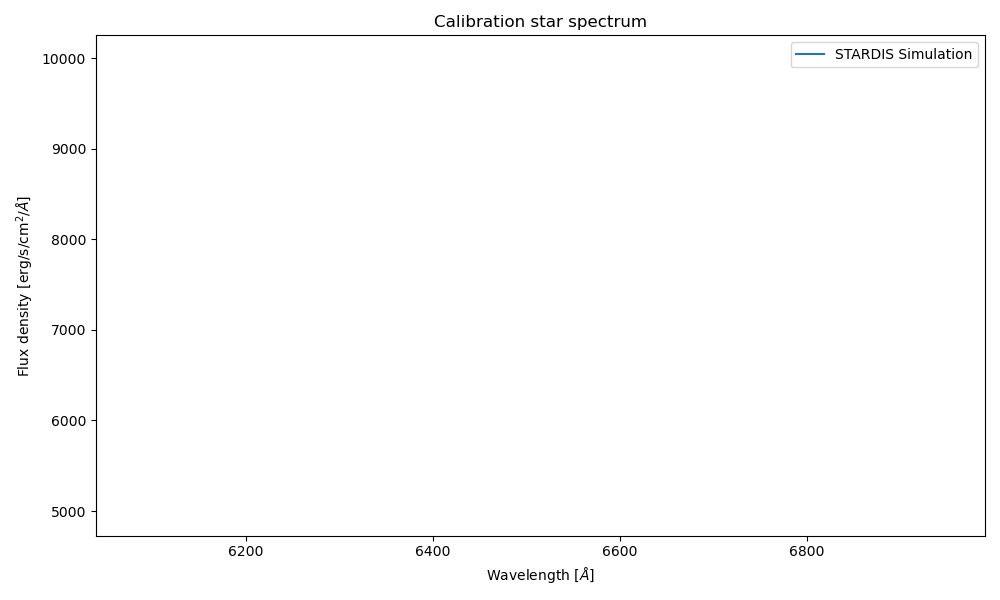

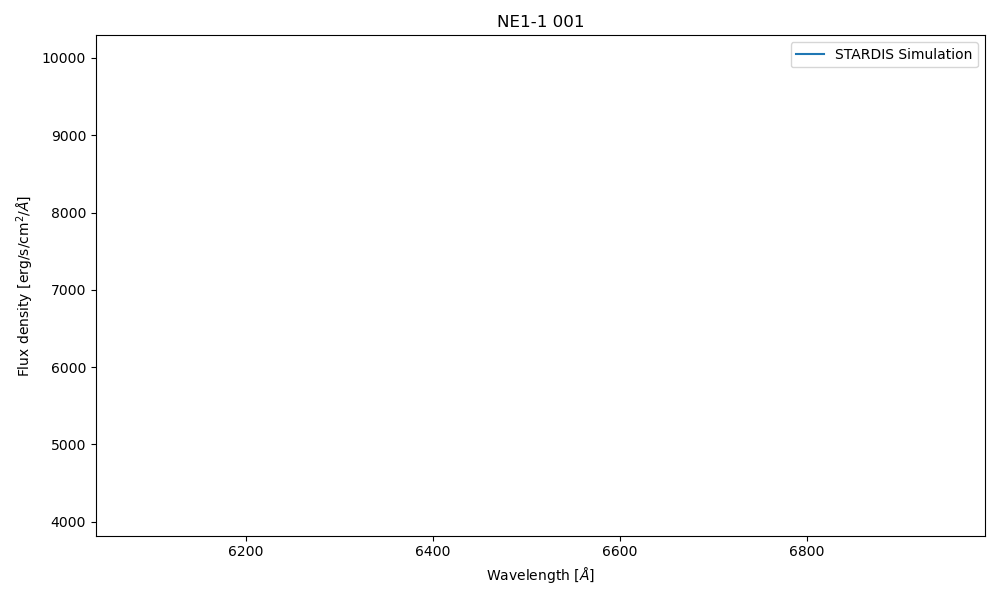

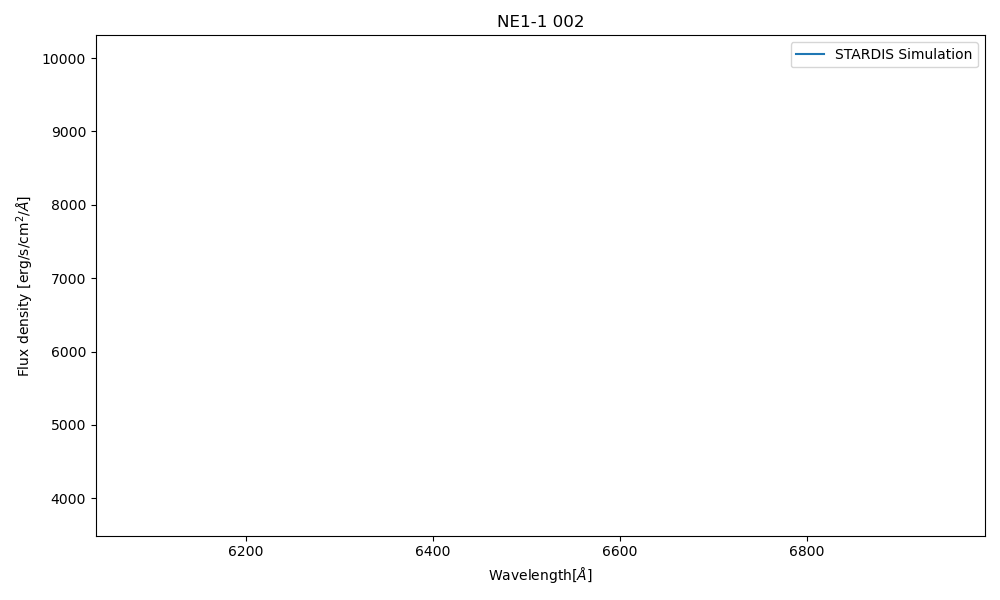

In [6]:
#Three plots for each target 
plt.figure(figsize=(10, 6))
plt.plot(
    sim_cal_lambdas,
    sim_cal_conv,
    label="STARDIS Simulation",
    color="tab:blue",
)
plt.xlim(6040, 6990)
plt.title("Calibration star spectrum")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Flux density [erg/s/cm$^2$/$\AA$]")
plt.tight_layout()
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(
    sim_001_lambdas,
    sim_001_conv,
    label="STARDIS Simulation",
    color="tab:blue",
)
plt.xlim(6040, 6990)
plt.title("NE1-1 001")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Flux density [erg/s/cm$^2$/$\AA$]")
plt.tight_layout()
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(
    sim_002_lambdas,
    sim_002_conv,
    label="STARDIS Simulation",
    color="tab:blue",
)
plt.xlim(6040, 6990)
plt.title("NE1-1 002")
plt.xlabel(r"Wavelength[$\AA$]")
plt.ylabel(r"Flux density [erg/s/cm$^2$/$\AA$]")
plt.tight_layout()
plt.legend()
plt.show()

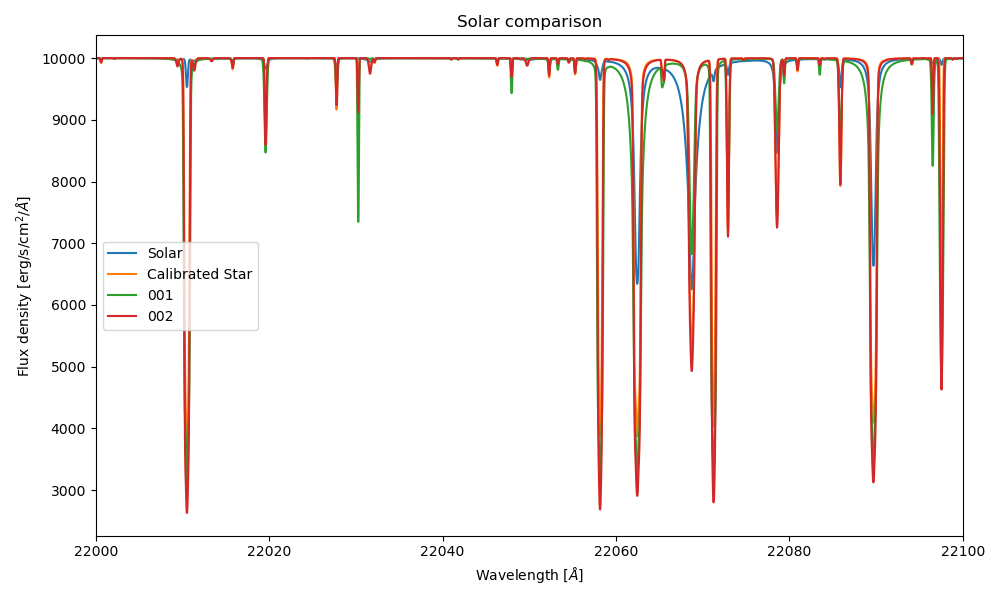

In [10]:
# Single plot for solar comparison with other targets 
plt.figure(figsize=(10, 6))
plt.plot(
    sim_sun_lambdas,sim_sun_conv,label="Solar"
    )
plt.plot(
    sim_cal_lambdas,sim_cal_conv,label="Calibrated Star"    
)
plt.plot(
    sim_001_lambdas,sim_001_conv,label="001"
)
plt.plot(
    sim_002_lambdas,sim_002_conv,label="002",color="tab:red"
)

plt.xlim(22000, 22100)
plt.title("Solar comparison")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Flux density [erg/s/cm$^2$/$\AA$]")
plt.tight_layout()
plt.legend()
plt.show()

In [7]:
# This cell and the next one try to extract spectrum from FITS file for calibration star
# Not working yet
# The FITS file was obtained from KECK Observatory Archive - Filtered by location coordinates and PI -> Do, UCLA


filename = "../data/Cal_star.fits"

with fits.open(filename) as hdul:
    hdul.info()

    for i, hdu in enumerate(hdul):
        print(f"\n--- HDU {i}: {hdu.name} ---")
        print("Type:", type(hdu).__name__)

        if hdu.data is not None:
            print("Data shape:", hdu.data.shape)
            if hasattr(hdu.data, "names"):
                print("Columns:", hdu.data.names)

        print("Header keys:", list(hdu.header.keys())[:20])

Filename: ../data/Cal_star.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     251   (1024, 1024)   int32   

--- HDU 0: PRIMARY ---
Type: PrimaryHDU
Data shape: (1024, 1024)
Header keys: ['SIMPLE', 'BITPIX', 'NAXIS', 'NAXIS1', 'NAXIS2', 'BSCALE', 'BZERO', 'TELESCOP', 'OBSERVER', 'OBJECT', 'COMMENT', 'ROOTNAME', 'FILENUM', 'FILENAME', 'OUTDIR', 'SCRIPTNA', 'FILNAME', 'SLITNAME', 'SLITPA', 'SLITX']


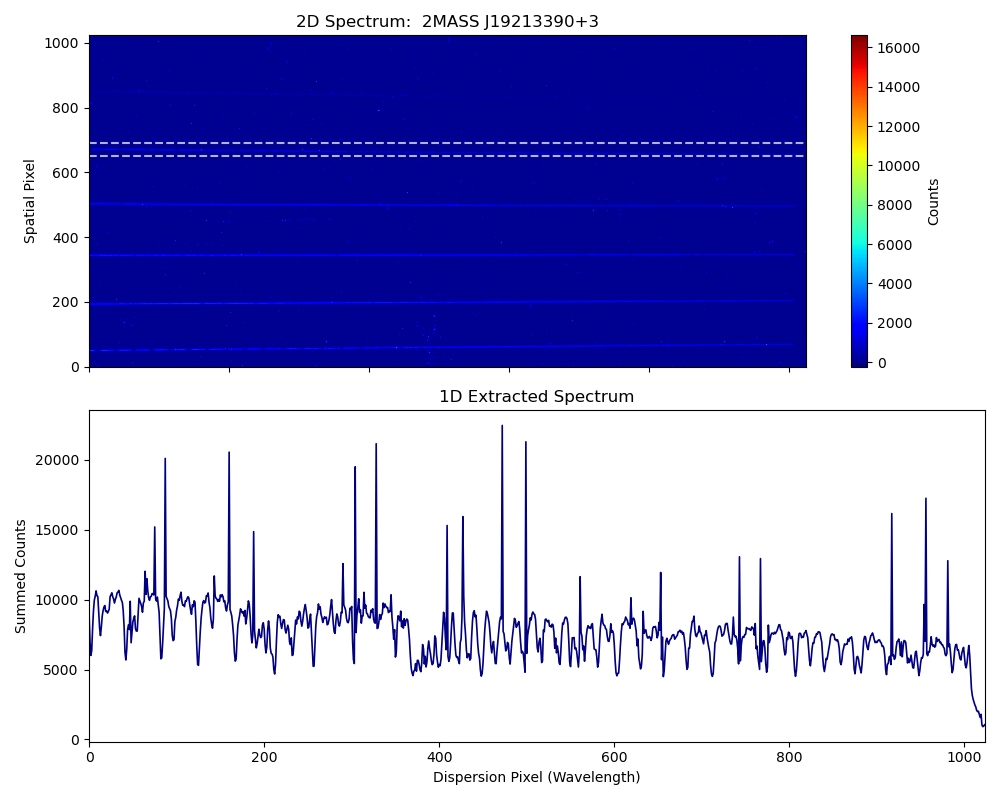

In [8]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

# Open the FITS file
with fits.open('../data/Cal_star.fits') as hdul:
    data = hdul[0].data
    header = hdul[0].header

# Create a figure to display both the 2D trace and the extracted 1D spectrum
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 1. Plot the 2D spectrum image
im = ax1.imshow(data, origin='lower', cmap='jet', aspect='auto')
ax1.set_title('2D Spectrum: ' + header.get('OBJECT', 'Cal_star'))
ax1.set_ylabel('Spatial Pixel')
fig.colorbar(im, ax=ax1, label='Counts')

# Highlight the estimated spatial region of the stellar trace (adjust bounds based on your data)
trace_min, trace_max = 650, 690
ax1.axhline(trace_min, color='white', linestyle='--', alpha=0.7)
ax1.axhline(trace_max, color='white', linestyle='--', alpha=0.7)

# 2. Extract and plot the 1D spectrum by collapsing the spatial axis across the trace
spectrum_1d = np.sum(data[trace_min:trace_max, :], axis=0)

ax2.plot(spectrum_1d, color='navy', lw=1.2)
ax2.set_title('1D Extracted Spectrum')
ax2.set_xlabel('Dispersion Pixel (Wavelength)')
ax2.set_ylabel('Summed Counts')

plt.tight_layout()
plt.show()

Filename: ../data/Cal_star.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     251   (1024, 1024)   float64   


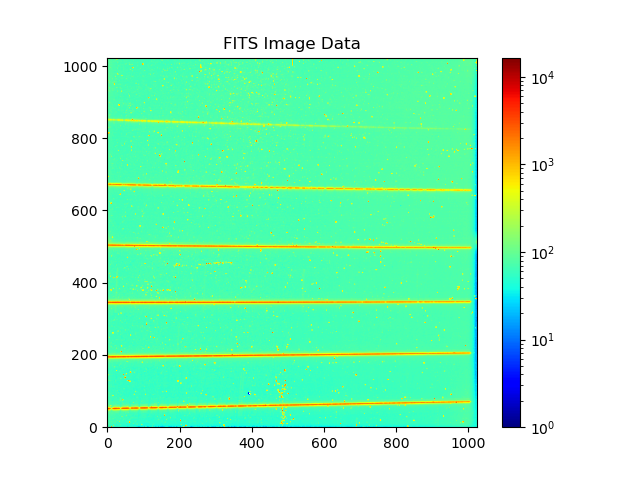

In [9]:
from matplotlib.colors import LogNorm
with fits.open('../data/Cal_star.fits') as hdul:
    data = hdul[0].data
    header = hdul[0].header
    hdul.info()
plt.figure()
plt.imshow(data, norm = LogNorm(), origin='lower', cmap='jet')
plt.colorbar()
plt.title('FITS Image Data')
plt.show()